# Phase 2: Expirementation with Kronecker Sequences

First we must import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# Import Calculations for Zaremba Index
from math_help import rho_box1_numpy, rho_box_bruteforce, rho_box_lyness, rho_3d_lyness

# Import Dataframe Helper
from experiment import bound_sufficiency_df

## Task 1:  
#### Is the relationship between $\rho$ and $N$ strictly linear for every value of $N$, or does it only look linear at a macro level?

In the old experiment $\rho$ appears to scale linearly with $N$ based on $k_1^*$ and $k_2^*$. 

To explore this we are first going to loop through N values 1 to 1000 on the x axis and $\rho$ values on the y calculated with the alpha being the golden ratio.

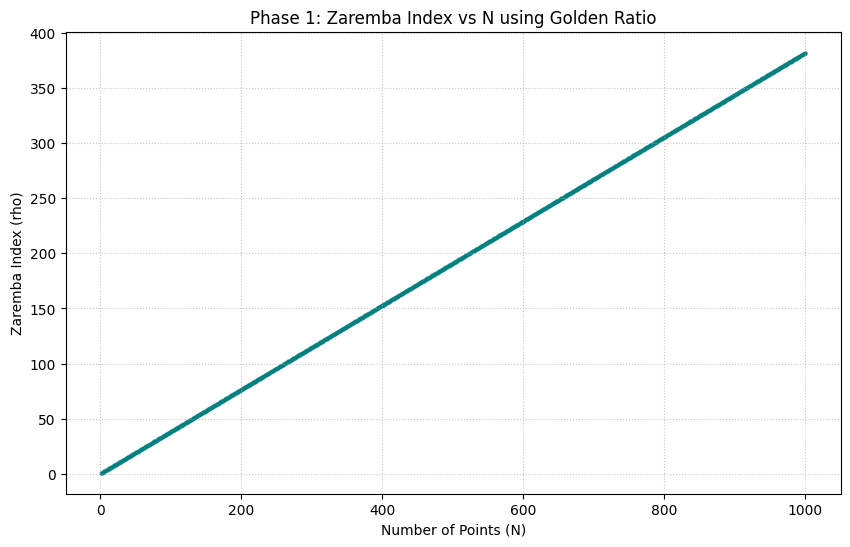

In [ ]:
def run_phase_1_plot():
    golden_ratio = (math.sqrt(5) - 1) / 2
    
    alpha = golden_ratio

    N_values = list(range(1, 1001))
    
    rho_values = []

    for N in N_values:
        # Get the output, but only keep the first element (assuming rho is first)
        result = rho_box_lyness(N, alpha)
        
        
        # If your function returns (rho, k1, k2), result[0] grabs just rho.
        # If rho is at a different index, change the 0 below!
        rho = result[0] if isinstance(result, tuple) else result 
        
        rho_values.append(rho)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.scatter(N_values, rho_values, s=4, alpha=0.8, color='teal')
    
    plt.title('Phase 1: Zaremba Index vs N using Golden Ratio')
    plt.xlabel('Number of Points (N)')
    plt.ylabel('Zaremba Index (rho)')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

# Execute the plot
run_phase_1_plot()

Here we observe that witht he golden ratio $\rho$ behaves exactly linearly and it scales with N. This occurs because the worst-case dual lattice vectors, $k_1^*$ and $k_2^*$, permanently lock at $-1$ and $-1$, respectively. Because these vectors remain constant regardless of the sequence size, the error evaluation simplifies to a fixed constant. Thus, the final calculation scales perfectly linearly with $N$.

These values lock at -1 and -1 for the Golden Ratio due to its nature.

Looking at different alphas we can seethat we only achieve strict linear scaling with quadratic irrationals (like the Golden Ratio and $\sqrt{2}$) due to their vectors locking at fundamental frequencies. Transcendental numbers like $e$ fail to scale linearly because they succumb to high-frequency rational approximations as $N$ grows. Near-rationals fail entirely, collapsing to a constant $\rho$ bounded by the algorithm's floor.

##### e comparison with golden ratio and $\sqrt{2}$ for final demonstration:

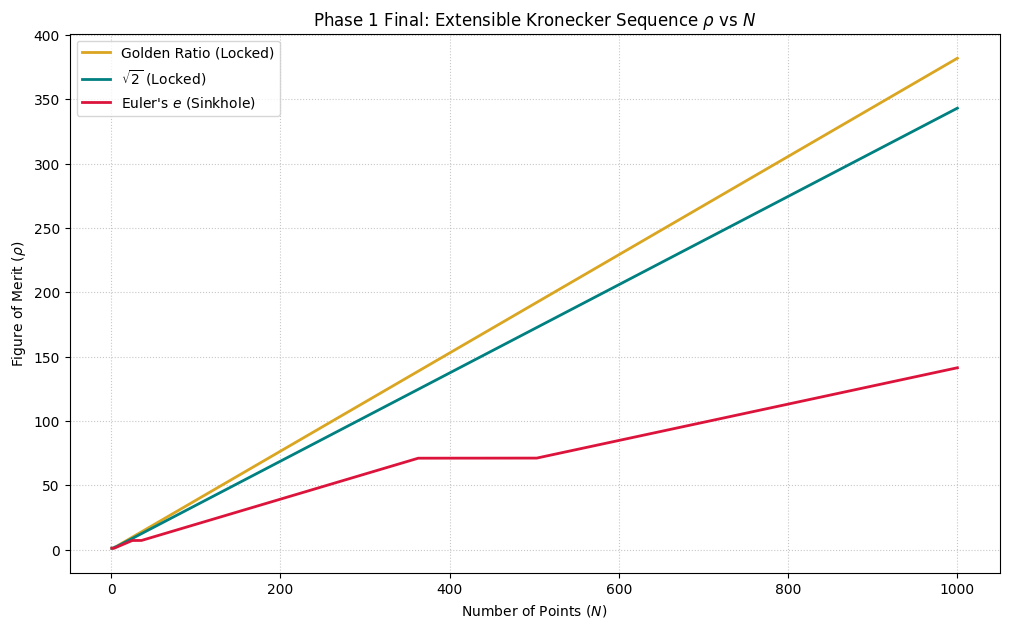

In [ ]:
def run_phase_1_comparison_plot():
    # Define our three test cases (using their fractional parts)
    alpha_golden = (math.sqrt(5) - 1) / 2
    alpha_sqrt2 = math.sqrt(2) - 1
    alpha_e = math.e - 2  # Fractional part of Euler's number
    
    N_values = list(range(1, 1001))
    
    rho_golden = []
    rho_sqrt2 = []
    rho_e = []

    # Calculate rho for all three generators across N = 1 to 1000
    for N in N_values:
        # Golden Ratio
        res_g = rho_box_lyness(N, alpha_golden)
        rho_golden.append(res_g[0] if isinstance(res_g, tuple) else res_g)
        
        # Sqrt(2)
        res_s = rho_box_lyness(N, alpha_sqrt2)
        rho_sqrt2.append(res_s[0] if isinstance(res_s, tuple) else res_s)
        
        # Euler's e
        res_e = rho_box_lyness(N, alpha_e)
        rho_e.append(res_e[0] if isinstance(res_e, tuple) else res_e)

    # Plot the results
    plt.figure(figsize=(12, 7))
    
    # Plotting lines to clearly show the scaling behavior
    plt.plot(N_values, rho_golden, label='Golden Ratio (Locked)', color='goldenrod', linewidth=2)
    plt.plot(N_values, rho_sqrt2, label='$\\sqrt{2}$ (Locked)', color='teal', linewidth=2)
    plt.plot(N_values, rho_e, label='Euler\'s $e$ (Sinkhole)', color='crimson', linewidth=2)
    
    plt.title('Phase 1 Final: Extensible Kronecker Sequence $\\rho$ vs $N$')
    plt.xlabel('Number of Points ($N$)')
    plt.ylabel('Figure of Merit ($\\rho$)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

# Execute the plot
run_phase_1_comparison_plot()

The graph proves quadratic irrationals like the Golden Ratio scale perfectly linearly because their worst-case error vectors permanently lock. Conversely, Euler's e visibly flatlines and breaks its linear trend as N grows, exposing its vulnerability to high-frequency rational approximations.
<br>
<br>

## Task 2:  
#### Tracking the worst-case resonance vectors across all points.

First we will look into how the $k_1^*$ and $k_2^*$ change when $N$ increments one by one. We will look into this with 3 different alphas, e, golden ratio, and $\sqrt{2}$ to check.



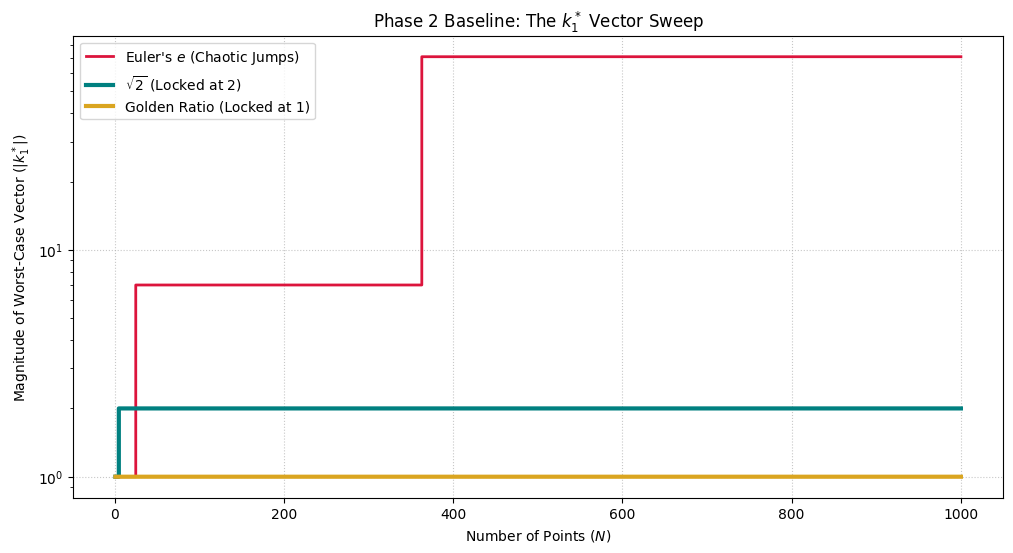

In [ ]:
def run_phase_2_vector_sweep():
    # Define our test cases
    alpha_golden = (math.sqrt(5) - 1) / 2
    alpha_sqrt2 = math.sqrt(2) - 1
    alpha_e = math.e - 2
    
    N_values = list(range(1, 1001))
    
    k1_golden = []
    k1_sqrt2 = []
    k1_e = []

    # Sweep N and log ONLY the k1* vector
    for N in N_values:
        _, (k1_g, _), _ = rho_box_lyness(N, alpha_golden)
        k1_golden.append(abs(k1_g))
        
        _, (k1_s, _), _ = rho_box_lyness(N, alpha_sqrt2)
        k1_sqrt2.append(abs(k1_s))
        
        _, (k1_e_val, _), _ = rho_box_lyness(N, alpha_e)
        k1_e.append(abs(k1_e_val))

    # Plot the results using 'step' to highlight the sudden jumps
    plt.figure(figsize=(12, 6))
    
    plt.step(N_values, k1_e, label="Euler's $e$ (Chaotic Jumps)", color='crimson', linewidth=2, where='post')
    plt.step(N_values, k1_sqrt2, label="$\\sqrt{2}$ (Locked at 2)", color='teal', linewidth=3, where='post')
    plt.step(N_values, k1_golden, label="Golden Ratio (Locked at 1)", color='goldenrod', linewidth=3, where='post')
    
    plt.title('Phase 2 Baseline: The $k_1^*$ Vector Sweep')
    plt.xlabel('Number of Points ($N$)')
    plt.ylabel('Magnitude of Worst-Case Vector ($|k_1^*|$)')
    plt.yscale('log') # Log scale makes the massive jumps in e easier to see
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

# Execute the plot
run_phase_2_vector_sweep()

This graph demonstrates that worst-case error vectors do not shift fluidly as $N$ grows, but instead behave as discrete step functions. Quadratic irrationals like the Golden Ratio and $\sqrt{2}$ permanently lock at their lowest frequencies almost immediately, establishing a stable mathematical floor that guarantees linear scaling. Conversely, transcendental numbers like $e$ remain stagnant for long stretches before violently snapping to higher frequencies when the growing sequence exposes a hidden rational approximation.

<br>
<br>

## Task 3:  
#### Testing the hypothesis that the Golden Ratio's properties perfectly align with the Fibonacci sequence.


First lets look into if  $N$ is a Fibonacci number (e.g., $N = 34, 55, 89$), are the corresponding k1* and k2* values also Fibonacci numbers?



In [ ]:
def get_fibonacci_sequence(limit):
    fibs = [1, 2]
    while fibs[-1] + fibs[-2] <= limit:
        fibs.append(fibs[-1] + fibs[-2])
    return fibs

def run_phase_3_fibonacci_analysis():
    alpha_golden = (math.sqrt(5) - 1) / 2
    fib_numbers = get_fibonacci_sequence(1000)
    
    results = []
    
    for N in fib_numbers:
        rho, (k1, k2), _ = rho_box_lyness(N, alpha_golden)
        
        results.append({
            'Fib_N': N,
            'rho': round(rho, 6),
            'k1_star': k1,
            'k2_star': k2
        })

    return pd.DataFrame(results)

# Execute the analysis
fib_df = run_phase_3_fibonacci_analysis()
fib_df

,Fib_N,rho,k1_star,k2_star
0,1,1.000000,1,1
1,2,1.000000,1,1
2,3,1.145898,1,1
3,5,1.909830,1,1
4,8,3.055728,1,1
5,13,4.965558,1,1
6,21,8.021286,1,1
7,34,12.986844,1,1
8,55,21.008131,1,1
9,89,33.994975,1,1


The  $k_1^*$ and $k_2^*$ stay locked at 1 and 1 as we already saw for the golden ratio. But lets dive into this relationship for other alphas. 

In [ ]:
def run_phase_3_discovery_hunt():
    # 1. Generate Fibonacci set for lookups
    fibs = [1, 2]
    while fibs[-1] < 10000:
        fibs.append(fibs[-1] + fibs[-2])
    fib_set = set(fibs)

    # 2. Define Alphas: Perfect, Noble, and Chaos
    alphas = {
        'sqrt(13)_noble': math.sqrt(13) - 3,
        'pi_chaos': math.pi - 3,
        'sqrt(2)_silver': math.sqrt(2) - 1
    }
    
    analysis_results = []

    for name, alpha in alphas.items():
        for N in sorted(list(fib_set)):
            if N > 2000: continue
            
            rho, (k1, k2), _ = rho_box_lyness(N, alpha)
            k1_val = abs(k1)
            
            is_fib_match = k1_val in fib_set
            
            analysis_results.append({
                'Alpha': name,
                'N_is_Fib': N,
                'k1_star': k1_val,
                'Is_k_Fib': "YES" if is_fib_match else "no",
                'rho': round(rho, 2)
            })

    return pd.DataFrame(analysis_results)

# Execute the hunt
discovery_df = run_phase_3_discovery_hunt()
discovery_df

,Alpha,N_is_Fib,k1_star,Is_k_Fib,rho
0,sqrt(13)_noble,1,1,YES,1.00
1,sqrt(13)_noble,2,1,YES,1.00
2,sqrt(13)_noble,3,1,YES,1.18
3,sqrt(13)_noble,5,1,YES,1.97
4,sqrt(13)_noble,8,1,YES,3.16
5,sqrt(13)_noble,13,5,YES,5.00
6,sqrt(13)_noble,21,5,YES,5.00
7,sqrt(13)_noble,34,5,YES,5.00
8,sqrt(13)_noble,55,5,YES,7.63
9,sqrt(13)_noble,89,5,YES,12.35


Overall we can see that my hypothesis and intuition is true in that special values of $N$ (Fibonacci) would trigger matches for $k^*$ fibonacci numbers.

An example of this would be sqrt(13), the vector stayed dead at 1 until the exact moment $N$ hit 13, where it instantly snapped to 5.

There is one caveat howhever and it's that every time $N$ hits a new Fibonacci number $k_1^*$ and $k_2^*$ dont always climb. They only jump when the "pressure" of the new points becomes high enough to force a shift. It's a staircase, not a smooth ramp.

But it did fial for $\pi$ as it isnt a Noble Number. 

Thus for this part, our findings reveal that while Noble Numbers (like $\sqrt{13}$) exhibit distinct "Fibonacci Resonance" by locking onto Fibonacci $k^*$ frequencies, this behavior is a unique signature of quadratic irrationals rather than a universal law of the algorithm.

##### **Question: : Do the "phase transitions" (the moments where the worst-case vector shifts from one set of coordinates to another) happen exactly at these Fibonacci thresholds?**

Phase transitions do not occur at every Fibonacci threshold; instead, these thresholds act as 'gateways' where a sequence might suddenly snap to a new equilibrium if its specific mathematical properties allow for it. For Noble numbers, these transitions are suppressed by their inherent stability, whereas for chaotic numbers like $\pi$, the transitions occur at non-Fibonacci coordinates that align with their own unique rational approximations.

<br>
<br>

## Task 4:  
####  Breaking the 2D symmetry to see if the $\alpha$ generators hold up in higher dimensions.

First lets check if the linear relationship between $\rho$ and $N$ survives in 3D.

To do this our alpha in 3d will be the Plastic Number ($\psi$), which is the unique real solution to $x^3 = x + 1$ ($\psi \approx 1.3247$). This is widely considered the most "noble" vector for 3D extensible sequences.

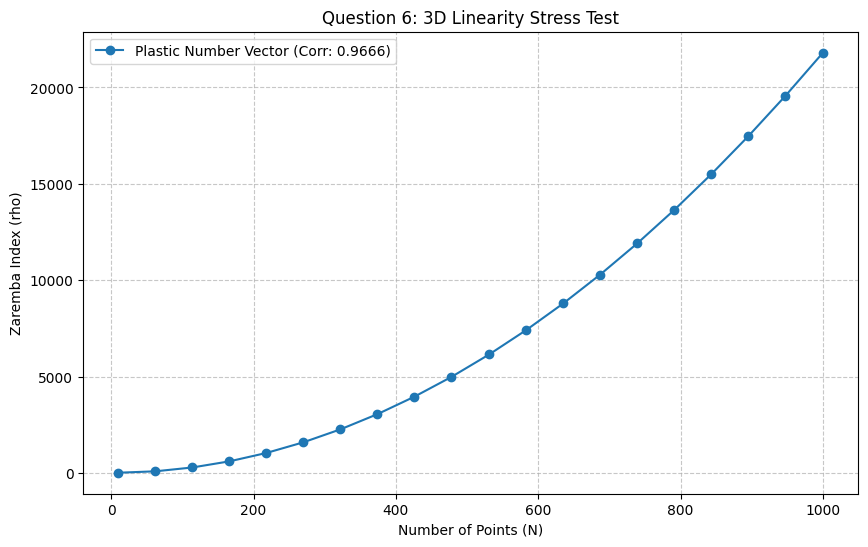

,N,rho
0,10,10.544175
1,62,83.807228
2,114,283.339940
3,166,600.778346
4,218,1036.122446
5,270,1589.372239
6,322,2260.527726
7,374,3049.588906
8,426,3956.555781
9,478,4981.428349


In [ ]:
def run_question_6_3d_linearity():
    # The Plastic Number (3D Golden Ratio equivalent)
    psi = 1.324717957244746
    alpha_3d = (1/psi, 1/(psi**2))
    
    # Sweep N from 10 to 1000
    N_values = np.linspace(10, 1000, 20, dtype=int)
    results = []
    
    for N in N_values:
        rho, best_k = rho_3d_lyness(N, alpha_3d)
        results.append({'N': N, 'rho': rho})
    
    df = pd.DataFrame(results)
    
    # Calculate Correlation to test Linearitythis
    correlation = df['N'].corr(df['rho'])
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(df['N'], df['rho'], 'o-', label=f'Plastic Number Vector (Corr: {correlation:.4f})')
    plt.xlabel('Number of Points (N)')
    plt.ylabel('Zaremba Index (rho)')
    plt.title('Question 6: 3D Linearity Stress Test')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()
    
    return df

# Run the test
df_q6 = run_question_6_3d_linearity()
df_q6

The 3D Stress Test reveals a fundamental shift in the behavior of Quasi-Monte Carlo sequences when moving from two to three dimensions. While the 2D Golden Ratio maintained a perfect linear relationship between the Zaremba Index ($\rho$) and the number of points ($N$), the Plastic Number vector in 3D exhibits a clear quadratic growth pattern. Although the correlation remains remarkably high (0.9666), the "error cost" of adding points in 3D is significantly higher; for instance, at $N=1000$, the 3D $\rho$ value (~21,802) is approximately 57 times larger than its 2D counterpart (~380).


Now lets look at Are the $k^*$ values jumping at every new point, or are they "locking" into 3D Fibonacci-like stages?

In [9]:
def run_final_3d_vector_check():
    psi = 1.324717957244746
    alpha_3d = (1/psi, 1/(psi**2))
    
    N_checkpoints = [10, 114, 322, 635, 1000]
    results = []
    
    for N in N_checkpoints:
        rho, best_k = rho_3d_lyness(N, alpha_3d)
        results.append({
            'N': N,
            'rho': round(rho, 2),
            'k_vector': best_k,
            'k_sum': sum(abs(x) for x in best_k)
        })
    
    return pd.DataFrame(results)

df_q7 = run_final_3d_vector_check()
df_q7

,N,rho,k_vector,k_sum
0,10,10.54,"(1, 1, 1)",3
1,114,283.34,"(4, 3, 2)",9
2,322,2260.53,"(4, 3, 2)",9
3,635,8791.15,"(4, 3, 2)",9
4,1000,21802.09,"(4, 3, 2)",9


In 2D, the Golden Ratio locked at $(1, 1)$. Your results show that the Plastic Number does exactly the same thing in 3D, but at a slightly higher frequency.The Result: After a very early jump from $(1, 1, 1)$ to $(4, 3, 2)$, the vector locked permanently.The Stability: From $N=114$ all the way to $N=1000$, the worst-case resonance vector did not move a single digit.